<a href="https://colab.research.google.com/github/Dhanshree010/pattern-recognition-practical/blob/main/practical_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

%matplotlib inline

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


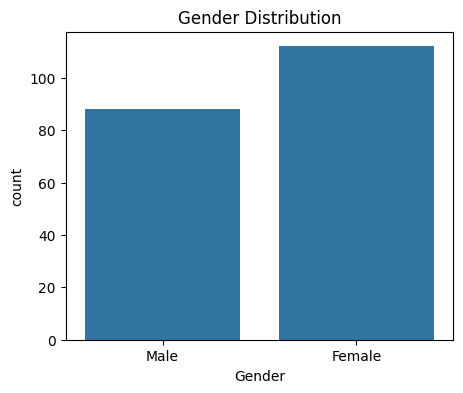

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.show()

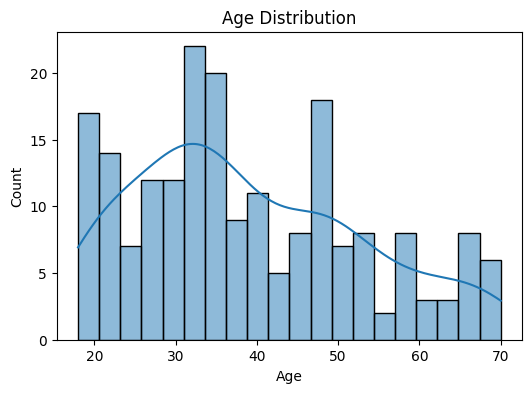

In [6]:
plt.figure(figsize=(6,4))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

In [9]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

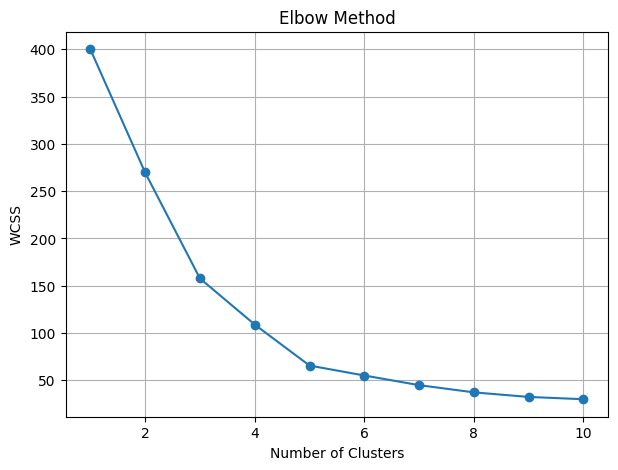

In [11]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid()

plt.show()

In [12]:
kmeans = KMeans(n_clusters=5,
                random_state=42,
                n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

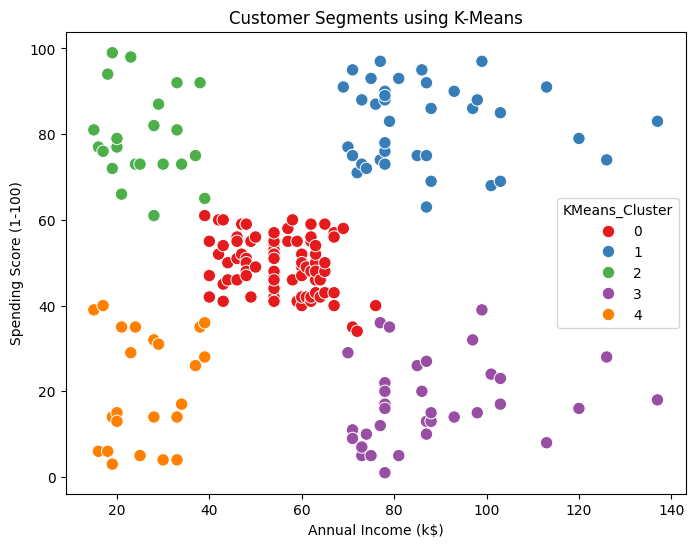

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='Set1',
    data=df,
    s=80
)

plt.title("Customer Segments using K-Means")

plt.show()

In [14]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.5546571631111091


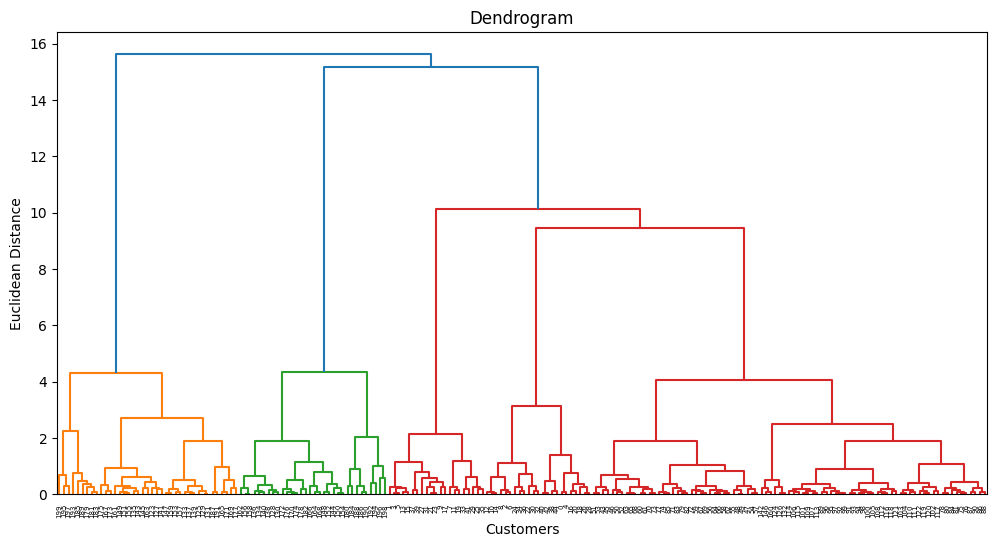

In [15]:
plt.figure(figsize=(12,6))

linked = linkage(X_scaled,
                 method='ward')

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [16]:
hc = AgglomerativeClustering(n_clusters=5)

hc_labels = hc.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hc_labels

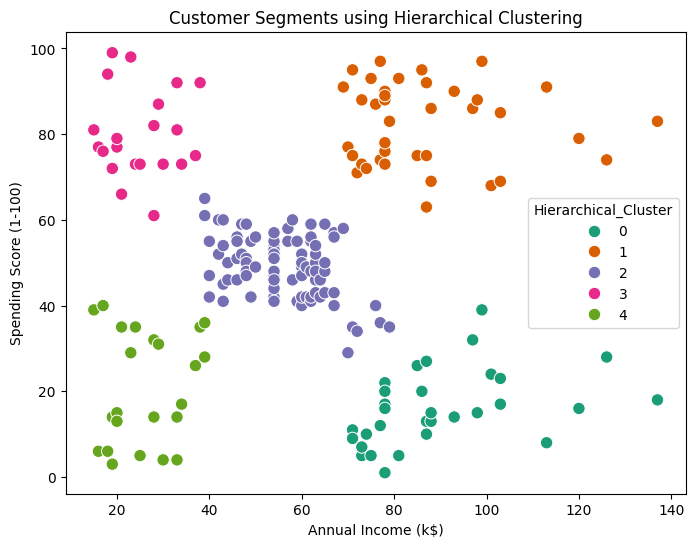

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Hierarchical_Cluster',
    palette='Dark2',
    data=df,
    s=80
)

plt.title("Customer Segments using Hierarchical Clustering")

plt.show()

In [18]:
print("K-Means Clusters")

print(df['KMeans_Cluster'].value_counts())

K-Means Clusters
KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [19]:
print("Hierarchical Clusters")

print(df['Hierarchical_Cluster'].value_counts())

Hierarchical Clusters
Hierarchical_Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64


In [20]:
cluster_summary = df.groupby("KMeans_Cluster")[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043
